# Metrics Summary — version_3

Lightning logs에서 기록된 validation metric을 task별로 정리합니다.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

CSV_PATH = "../../lightning_logs/version_3/metrics.csv"
raw = pd.read_csv(CSV_PATH)

# validation 행만 추출 (train/loss가 NaN인 행 = validation 기록)
val_rows = raw[raw["train/loss"].isna()].copy()
val_rows = val_rows.set_index("epoch")

# validation 컬럼만 추출
val_cols = [c for c in val_rows.columns if c.startswith("val/")]
val_df = val_rows[val_cols].copy()

# inf → NaN 처리
val_df.replace([np.inf, -np.inf], np.nan, inplace=True)

print(f"Epochs: {sorted(val_df.index.unique().tolist())}")
print(f"Total val metrics: {len(val_cols)}")
val_df.head()

Epochs: [0, 1, 2]
Total val metrics: 73


,val/bace/accuracy,val/bace/f1,val/bace/failure_rate,val/bace/roc_auc,val/chebi-20-mol2text/bleu2,val/chebi-20-mol2text/bleu4,val/chebi-20-mol2text/failure_rate,val/chebi-20-mol2text/rouge1,val/chebi-20-mol2text/rougeL,val/chebi-20-text2mol/exact_match_ratio,...,val/smol-property_prediction-lipo/mae,val/smol-property_prediction-lipo/rmse,val/smol-property_prediction-sider/accuracy,val/smol-property_prediction-sider/f1,val/smol-property_prediction-sider/failure_rate,val/smol-property_prediction-sider/roc_auc,val/smol-retrosynthesis/exact_match_ratio,val/smol-retrosynthesis/failure_rate,val/smol-retrosynthesis/levenshtein_score,val/smol-retrosynthesis/validity_ratio
epoch,,,,,,,,,,,,,,,,,,,,,
0,0.669872,0.000000,0.0,0.458898,0.0,0.0,1.0,0.0,0.0,0.0,...,NaN,NaN,0.218750,0.000000,0.0,0.535056,0.0,1.0,0.0,0.0
1,0.330128,0.495915,0.0,0.425955,0.0,0.0,1.0,0.0,0.0,0.0,...,NaN,NaN,0.658654,0.750519,0.0,0.635627,0.0,1.0,0.0,0.0
2,0.669872,0.000000,0.0,0.556510,0.0,0.0,1.0,0.0,0.0,0.0,...,NaN,NaN,0.218750,0.000000,0.0,0.509325,0.0,1.0,0.0,0.0


In [3]:
# Task별로 메트릭 그룹핑
from collections import defaultdict

task_metrics = defaultdict(list)
for col in val_cols:
    # val/<task>/<metric> 형태 파싱
    parts = col.split("/")
    task = "/".join(parts[1:-1])  # 중간이 task명
    metric = parts[-1]
    task_metrics[task].append((metric, col))

print(f"Tasks ({len(task_metrics)}):")
for t in sorted(task_metrics.keys()):
    metrics = [m[0] for m in task_metrics[t]]
    print(f"  {t}: {metrics}")

Tasks (19):
  bace: ['accuracy', 'f1', 'failure_rate', 'roc_auc']
  chebi-20-mol2text: ['bleu2', 'bleu4', 'failure_rate', 'rouge1', 'rougeL']
  chebi-20-text2mol: ['exact_match_ratio', 'failure_rate', 'levenshtein_score', 'validity_ratio']
  forward_reaction_prediction: ['exact_match_ratio', 'failure_rate', 'levenshtein_score', 'validity_ratio']
  qm9_homo: ['failure_rate', 'mae', 'rmse']
  qm9_homo_lumo_gap: ['failure_rate', 'mae', 'rmse']
  qm9_lumo: ['failure_rate', 'mae', 'rmse']
  reagent_prediction: ['exact_match_ratio', 'failure_rate', 'levenshtein_score', 'validity_ratio']
  retrosynthesis: ['exact_match_ratio', 'failure_rate', 'levenshtein_score', 'validity_ratio']
  smol-forward_synthesis: ['exact_match_ratio', 'failure_rate', 'levenshtein_score', 'validity_ratio']
  smol-molecule_captioning: ['bleu2', 'bleu4', 'failure_rate', 'rouge1', 'rougeL']
  smol-molecule_generation: ['exact_match_ratio', 'failure_rate', 'levenshtein_score', 'validity_ratio']
  smol-property_prediction

## 1. Classification Tasks

**bace, smol-property_prediction-*** (bbbp, clintox, hiv, sider)

Metrics: accuracy, f1, roc_auc, failure_rate

In [4]:
cls_tasks = ["bace", "smol-property_prediction-bbbp", "smol-property_prediction-clintox",
              "smol-property_prediction-hiv", "smol-property_prediction-sider"]

cls_display_metrics = ["accuracy", "f1", "roc_auc", "failure_rate"]

for task in cls_tasks:
    if task not in task_metrics:
        continue
    cols = {m: c for m, c in task_metrics[task] if m in cls_display_metrics}
    sub = val_df[list(cols.values())].rename(columns={v: k for k, v in cols.items()})
    sub.index.name = "epoch"
    print(f"\n{'='*60}")
    print(f"  {task}")
    print(f"{'='*60}")
    display(sub.round(4))


  bace


,accuracy,f1,failure_rate,roc_auc
epoch,,,,
0,0.6699,0.0000,0.0,0.4589
1,0.3301,0.4959,0.0,0.4260
2,0.6699,0.0000,0.0,0.5565



  smol-property_prediction-bbbp


,accuracy,f1,failure_rate,roc_auc
epoch,,,,
0,0.2492,0.0000,0.0,0.5479
1,0.7508,0.8532,0.0,0.4834
2,0.5681,0.6575,0.0,0.4589



  smol-property_prediction-clintox


,accuracy,f1,failure_rate,roc_auc
epoch,,,,
0,0.9399,0.0,0.0,0.2701
1,0.9295,0.0,0.0,0.2212
2,0.9399,0.0,0.0,0.2733



  smol-property_prediction-hiv


,accuracy,f1,failure_rate,roc_auc
epoch,,,,
0,0.9591,0.0000,0.0,0.2150
1,0.8413,0.0833,0.0,0.2249
2,0.9591,0.0000,0.0,0.1364



  smol-property_prediction-sider


,accuracy,f1,failure_rate,roc_auc
epoch,,,,
0,0.2188,0.0000,0.0,0.5351
1,0.6587,0.7505,0.0,0.6356
2,0.2188,0.0000,0.0,0.5093


## 2. Regression Tasks
**qm9_homo, qm9_lumo, qm9_homo_lumo_gap, smol-property_prediction-esol, smol-property_prediction-lipo**

Metrics: mae, rmse, failure_rate

In [5]:
reg_tasks = ["qm9_homo", "qm9_lumo", "qm9_homo_lumo_gap",
             "smol-property_prediction-esol", "smol-property_prediction-lipo"]

reg_display_metrics = ["mae", "rmse", "failure_rate"]

for task in reg_tasks:
    if task not in task_metrics:
        continue
    cols = {m: c for m, c in task_metrics[task] if m in reg_display_metrics}
    sub = val_df[list(cols.values())].rename(columns={v: k for k, v in cols.items()})
    sub.index.name = "epoch"
    print(f"\n{'='*60}")
    print(f"  {task}")
    print(f"{'='*60}")
    display(sub.round(4))


  qm9_homo


,failure_rate,mae,rmse
epoch,,,
0,1.0,NaN,NaN
1,1.0,NaN,NaN
2,1.0,NaN,NaN



  qm9_lumo


,failure_rate,mae,rmse
epoch,,,
0,1.0,NaN,NaN
1,1.0,NaN,NaN
2,1.0,NaN,NaN



  qm9_homo_lumo_gap


,failure_rate,mae,rmse
epoch,,,
0,1.0,NaN,NaN
1,1.0,NaN,NaN
2,1.0,NaN,NaN



  smol-property_prediction-esol


,failure_rate,mae,rmse
epoch,,,
0,1.0,NaN,NaN
1,1.0,NaN,NaN
2,1.0,NaN,NaN



  smol-property_prediction-lipo


,failure_rate,mae,rmse
epoch,,,
0,1.0,NaN,NaN
1,1.0,NaN,NaN
2,1.0,NaN,NaN


## 3. Text Generation Tasks (Mol→Text)
**chebi-20-mol2text, smol-molecule_captioning**

Metrics: bleu2, bleu4, rouge1, rougeL, failure_rate

In [6]:
text_gen_tasks = ["chebi-20-mol2text", "smol-molecule_captioning"]
text_gen_metrics = ["bleu2", "bleu4", "rouge1", "rougeL", "failure_rate"]

for task in text_gen_tasks:
    if task not in task_metrics:
        continue
    cols = {m: c for m, c in task_metrics[task] if m in text_gen_metrics}
    sub = val_df[list(cols.values())].rename(columns={v: k for k, v in cols.items()})
    sub.index.name = "epoch"
    print(f"\n{'='*60}")
    print(f"  {task}")
    print(f"{'='*60}")
    display(sub.round(4))


  chebi-20-mol2text


,bleu2,bleu4,failure_rate,rouge1,rougeL
epoch,,,,,
0,0.0,0.0,1.0,0.0,0.0
1,0.0,0.0,1.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0



  smol-molecule_captioning


,bleu2,bleu4,failure_rate,rouge1,rougeL
epoch,,,,,
0,0.0,0.0,1.0,0.0,0.0
1,0.0,0.0,1.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0


## 4. Molecule Generation Tasks (Text→Mol)
**chebi-20-text2mol, smol-molecule_generation**

Metrics: exact_match_ratio, levenshtein_score, validity_ratio, failure_rate

In [7]:
mol_gen_tasks = ["chebi-20-text2mol", "smol-molecule_generation"]
mol_gen_metrics = ["exact_match_ratio", "levenshtein_score", "validity_ratio", "failure_rate"]

for task in mol_gen_tasks:
    if task not in task_metrics:
        continue
    cols = {m: c for m, c in task_metrics[task] if m in mol_gen_metrics}
    sub = val_df[list(cols.values())].rename(columns={v: k for k, v in cols.items()})
    sub.index.name = "epoch"
    print(f"\n{'='*60}")
    print(f"  {task}")
    print(f"{'='*60}")
    display(sub.round(4))


  chebi-20-text2mol


,exact_match_ratio,failure_rate,levenshtein_score,validity_ratio
epoch,,,,
0,0.0,1.0,0.0,0.0
1,0.0,1.0,0.0,0.0
2,0.0,1.0,0.0,0.0



  smol-molecule_generation


,exact_match_ratio,failure_rate,levenshtein_score,validity_ratio
epoch,,,,
0,0.0,1.0,0.0,0.0
1,0.0,1.0,0.0,0.0
2,0.0,1.0,0.0,0.0


## 5. Reaction Tasks
**forward_reaction_prediction, reagent_prediction, retrosynthesis, smol-forward_synthesis, smol-retrosynthesis**
Metrics: exact_match_ratio, levenshtein_score, validity_ratio, failure_rate

In [8]:
rxn_tasks = ["forward_reaction_prediction", "reagent_prediction", "retrosynthesis",
             "smol-forward_synthesis", "smol-retrosynthesis"]
rxn_metrics = ["exact_match_ratio", "levenshtein_score", "validity_ratio", "failure_rate"]

for task in rxn_tasks:
    if task not in task_metrics:
        continue
    cols = {m: c for m, c in task_metrics[task] if m in rxn_metrics}
    sub = val_df[list(cols.values())].rename(columns={v: k for k, v in cols.items()})
    sub.index.name = "epoch"
    print(f"\n{'='*60}")
    print(f"  {task}")
    print(f"{'='*60}")
    display(sub.round(4))


  forward_reaction_prediction


,exact_match_ratio,failure_rate,levenshtein_score,validity_ratio
epoch,,,,
0,0.0,1.0,0.0,0.0
1,0.0,1.0,0.0,0.0
2,0.0,1.0,0.0,0.0



  reagent_prediction


,exact_match_ratio,failure_rate,levenshtein_score,validity_ratio
epoch,,,,
0,0.0,1.0,0.0,0.0
1,0.0,1.0,0.0,0.0
2,0.0,1.0,0.0,0.0



  retrosynthesis


,exact_match_ratio,failure_rate,levenshtein_score,validity_ratio
epoch,,,,
0,0.0,1.0,0.0,0.0
1,0.0,1.0,0.0,0.0
2,0.0,1.0,0.0,0.0



  smol-forward_synthesis


,exact_match_ratio,failure_rate,levenshtein_score,validity_ratio
epoch,,,,
0,0.0,1.0,0.0,0.0
1,0.0,1.0,0.0,0.0
2,0.0,1.0,0.0,0.0



  smol-retrosynthesis


,exact_match_ratio,failure_rate,levenshtein_score,validity_ratio
epoch,,,,
0,0.0,1.0,0.0,0.0
1,0.0,1.0,0.0,0.0
2,0.0,1.0,0.0,0.0


## 6. Training Loss & Learning Rate

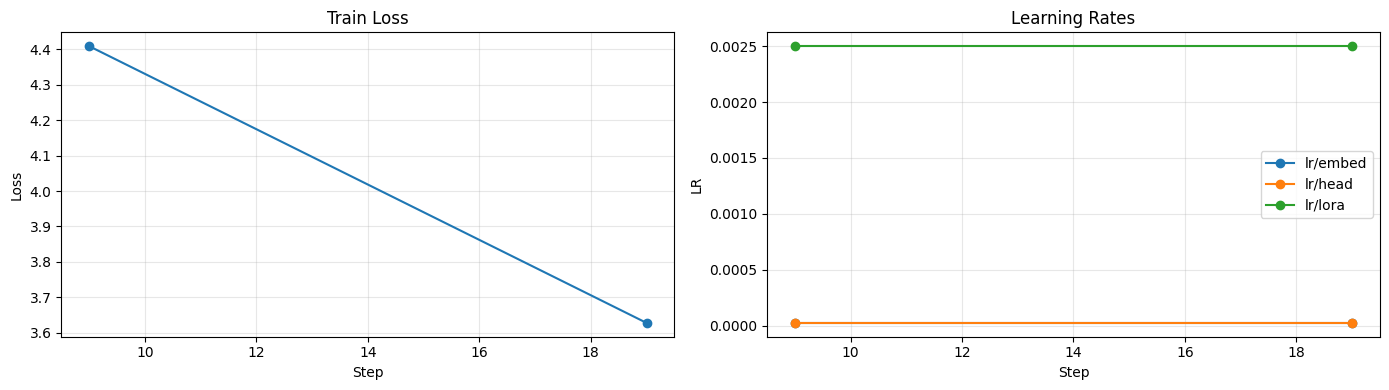

,epoch,step,train/loss,train/answer_length_mean,lr/embed,lr/head,lr/lora
1,1,9,4.408698,25.7500,0.000025,0.000025,0.0025
3,2,19,3.628045,28.1875,0.000025,0.000025,0.0025


In [9]:
train_rows = raw[raw["train/loss"].notna()].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Loss
axes[0].plot(train_rows["step"], train_rows["train/loss"], marker="o")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Loss")
axes[0].set_title("Train Loss")
axes[0].grid(True, alpha=0.3)

# Learning Rates
lr_cols = [c for c in train_rows.columns if c.startswith("lr/")]
for col in lr_cols:
    axes[1].plot(train_rows["step"], train_rows[col], marker="o", label=col)
axes[1].set_xlabel("Step")
axes[1].set_ylabel("LR")
axes[1].set_title("Learning Rates")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

display(train_rows[["epoch", "step", "train/loss", "train/answer_length_mean"] + lr_cols].round(6))

## 7. Key Metrics Overview (Heatmap)

각 task의 대표 metric을 epoch별로 한눈에 비교합니다.

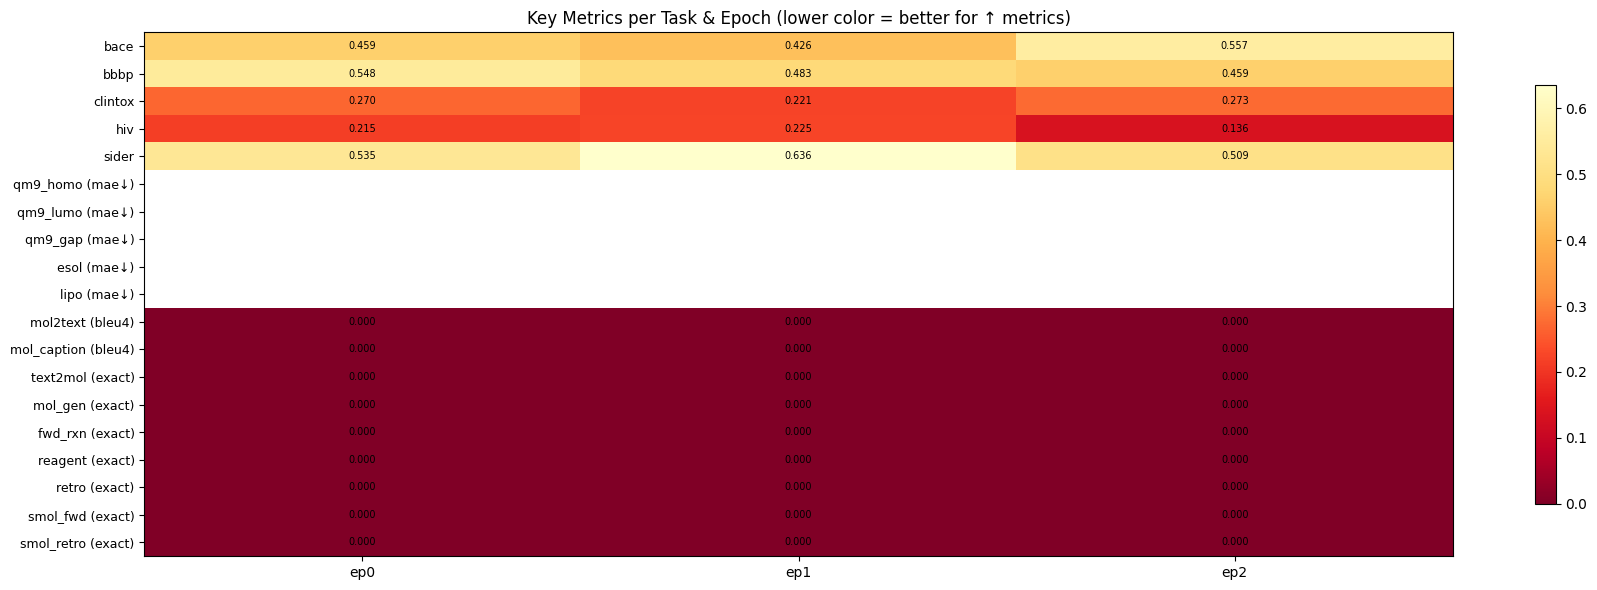

,bace,bbbp,clintox,hiv,sider,qm9_homo (mae↓),qm9_lumo (mae↓),qm9_gap (mae↓),esol (mae↓),lipo (mae↓),mol2text (bleu4),mol_caption (bleu4),text2mol (exact),mol_gen (exact),fwd_rxn (exact),reagent (exact),retro (exact),smol_fwd (exact),smol_retro (exact)
epoch,,,,,,,,,,,,,,,,,,,
0,0.4589,0.5479,0.2701,0.2150,0.5351,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.4260,0.4834,0.2212,0.2249,0.6356,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.5565,0.4589,0.2733,0.1364,0.5093,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [10]:
# 각 task의 "대표 metric" 선정 (higher is better 기준, regression은 -mae 사용)
key_metrics = {
    "bace": "val/bace/roc_auc",
    "bbbp": "val/smol-property_prediction-bbbp/roc_auc",
    "clintox": "val/smol-property_prediction-clintox/roc_auc",
    "hiv": "val/smol-property_prediction-hiv/roc_auc",
    "sider": "val/smol-property_prediction-sider/roc_auc",
    "qm9_homo (mae↓)": "val/qm9_homo/mae",
    "qm9_lumo (mae↓)": "val/qm9_lumo/mae",
    "qm9_gap (mae↓)": "val/qm9_homo_lumo_gap/mae",
    "esol (mae↓)": "val/smol-property_prediction-esol/mae",
    "lipo (mae↓)": "val/smol-property_prediction-lipo/mae",
    "mol2text (bleu4)": "val/chebi-20-mol2text/bleu4",
    "mol_caption (bleu4)": "val/smol-molecule_captioning/bleu4",
    "text2mol (exact)": "val/chebi-20-text2mol/exact_match_ratio",
    "mol_gen (exact)": "val/smol-molecule_generation/exact_match_ratio",
    "fwd_rxn (exact)": "val/forward_reaction_prediction/exact_match_ratio",
    "reagent (exact)": "val/reagent_prediction/exact_match_ratio",
    "retro (exact)": "val/retrosynthesis/exact_match_ratio",
    "smol_fwd (exact)": "val/smol-forward_synthesis/exact_match_ratio",
    "smol_retro (exact)": "val/smol-retrosynthesis/exact_match_ratio",
}

overview = pd.DataFrame(index=sorted(val_df.index.unique()))
overview.index.name = "epoch"
for label, col in key_metrics.items():
    if col in val_df.columns:
        overview[label] = val_df.loc[overview.index, col].values

fig, ax = plt.subplots(figsize=(18, 6))
data_plot = overview.T.astype(float)

im = ax.imshow(data_plot.values, aspect="auto", cmap="YlOrRd_r")
ax.set_xticks(range(len(data_plot.columns)))
ax.set_xticklabels([f"ep{e}" for e in data_plot.columns])
ax.set_yticks(range(len(data_plot.index)))
ax.set_yticklabels(data_plot.index, fontsize=9)

# 셀에 값 표시
for i in range(data_plot.shape[0]):
    for j in range(data_plot.shape[1]):
        v = data_plot.iloc[i, j]
        if pd.notna(v):
            ax.text(j, i, f"{v:.3f}", ha="center", va="center", fontsize=7)

plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Key Metrics per Task & Epoch (lower color = better for ↑ metrics)")
plt.tight_layout()
plt.show()

display(overview.round(4))

## 8. Failure Rate Overview

각 task의 failure_rate 추이를 확인합니다. (모델이 유효한 답변을 생성하지 못한 비율)

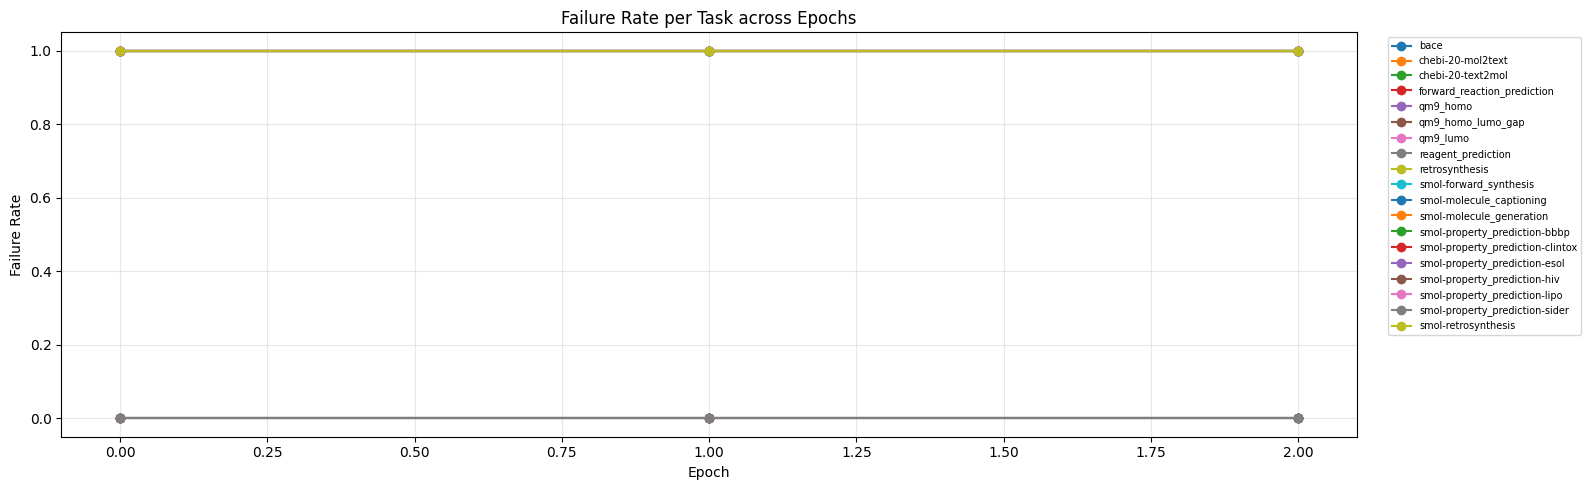

,bace,chebi-20-mol2text,chebi-20-text2mol,forward_reaction_prediction,qm9_homo,qm9_homo_lumo_gap,qm9_lumo,reagent_prediction,retrosynthesis,smol-forward_synthesis,smol-molecule_captioning,smol-molecule_generation,smol-property_prediction-bbbp,smol-property_prediction-clintox,smol-property_prediction-esol,smol-property_prediction-hiv,smol-property_prediction-lipo,smol-property_prediction-sider,smol-retrosynthesis
epoch,,,,,,,,,,,,,,,,,,,
0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
1,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
2,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0


In [11]:
failure_cols = {col: col.replace("val/", "").replace("/failure_rate", "")
                for col in val_cols if col.endswith("failure_rate")}

failure_df = val_df[list(failure_cols.keys())].rename(columns=failure_cols)
failure_df.index.name = "epoch"

fig, ax = plt.subplots(figsize=(16, 5))
for col in failure_df.columns:
    ax.plot(failure_df.index, failure_df[col], marker="o", label=col, linewidth=1.5)

ax.set_xlabel("Epoch")
ax.set_ylabel("Failure Rate")
ax.set_title("Failure Rate per Task across Epochs")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7)
ax.set_ylim(-0.05, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

display(failure_df.round(4))